# 06 — Scenario: Poor Inventory Allocation *(flagship notebook)*

**The situation, straight from the strategy brief:**

> We have units of a high-demand parka remaining globally. Where should each unit
> physically be tomorrow?

Toronto (Ontario) has been over-allocated on the season's two hero parkas; Vancouver
(Western Canada) has been under-allocated on the same styles — inventory sitting
unsold in one geography while another repeatedly stocks out. This notebook proves:
lost-sales inference, transfer optimization, allocation improvement, and margin
recovery — and reproduces the doc's own example almost exactly.

In [1]:
import sys
sys.path.insert(0, "../src")
import duckdb
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from retail_synth.viz import CATEGORICAL, SEQUENTIAL_BLUE, DIVERGING, STATUS, style_fig

pd.options.display.float_format = "{:,.1f}".format
con = duckdb.connect("../data/warehouse/retail.duckdb", read_only=True)
AS_OF = con.execute("SELECT week_start_date FROM silver.dim_week WHERE is_as_of_week").fetchone()[0]
print(f"Connected. AS_OF date = {AS_OF}")

Connected. AS_OF date = 2025-12-01


## Investigate — the Toronto / Vancouver drill-down

In [2]:
drill = con.execute("""
    SELECT st.city, sig.style_name, sig.color_name, sig.size, sig.on_hand_units,
           sig.overstock_pct, sig.stockout_est_days
    FROM gold.inventory_imbalance_signals sig
    JOIN silver.dim_store st ON st.store_id = sig.location_id
    WHERE st.city IN ('Toronto','Vancouver')
      AND sig.style_name IN ('Expedition Parka','Arctic Parka')
""").df()

toronto_overstock = drill.loc[(drill.city=='Toronto') & (drill.overstock_pct > 0)]
vancouver_short = drill.loc[(drill.city=='Vancouver') & (drill.stockout_est_days < 30)]

if len(toronto_overstock):
    # NOTE: use r["size"], not r.size -- .size as an attribute is pandas'
    # built-in Series.size (element count), not the "size" column.
    r = toronto_overstock.sort_values("overstock_pct", ascending=False).iloc[0]
    print(f"Toronto -- {r.style_name} {r.color_name}/{r['size']}: inventory projected to exceed "
          f"remaining-season demand by {r.overstock_pct * 100:.0f}%.")
if len(vancouver_short):
    r = vancouver_short.sort_values("stockout_est_days").iloc[0]
    print(f"Vancouver -- {r.style_name} {r.color_name}/{r['size']}: expected to stock out within "
          f"{r.stockout_est_days:.0f} days.")

Toronto -- Expedition Parka Black/XL: inventory projected to exceed remaining-season demand by 200%.
Vancouver -- Arctic Parka Stone/XXL: expected to stock out within 0 days.


## Investigate — portfolio-wide surplus vs. shortage

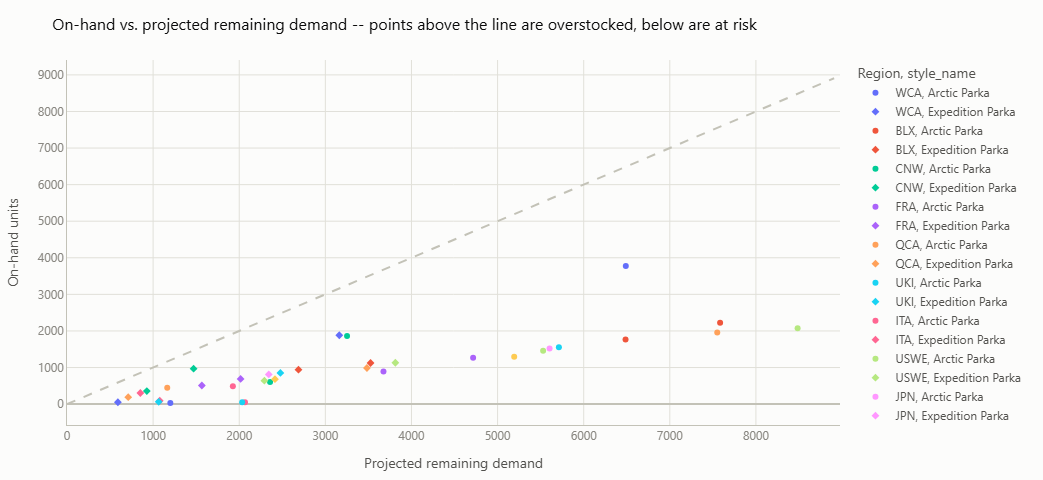

In [3]:
region_roll = con.execute("""
    SELECT region_code, style_name,
           SUM(on_hand_units) on_hand, SUM(projected_remaining_demand) proj_demand
    FROM gold.inventory_imbalance_signals
    WHERE style_name IN ('Expedition Parka','Arctic Parka') AND location_type='Store'
    GROUP BY 1, 2
""").df()
region_roll["overstock_pct"] = (region_roll.on_hand - region_roll.proj_demand) / region_roll.proj_demand * 100

fig = px.scatter(region_roll, x="proj_demand", y="on_hand", color="region_code", symbol="style_name",
                  labels={"proj_demand": "Projected remaining demand", "on_hand": "On-hand units", "region_code": "Region"})
max_v = max(region_roll.proj_demand.max(), region_roll.on_hand.max()) * 1.05
fig.add_trace(go.Scatter(x=[0, max_v], y=[0, max_v], mode="lines", line=dict(color="#c3c2b7", dash="dash"),
                          showlegend=False))
style_fig(fig, "On-hand vs. projected remaining demand -- points above the line are overstocked, below are at risk", height=480)

Ontario sits well above the diagonal (surplus); Western Canada and the Nordics sit below it (shortage) -- for the exact same two styles.

## Simulate — the 3-option transfer decision

In [4]:
surplus = region_roll.loc[region_roll.region_code.isin(["ONT"])]
shortage = region_roll.loc[region_roll.region_code.isin(["WCA"])]
transfer_units = int(min(surplus.on_hand.sum() * 0.4, shortage.proj_demand.sum() * 1.2))
avg_price = con.execute("""
    SELECT AVG(current_retail_price) FROM silver.dim_sku sku JOIN silver.dim_style sty ON sty.style_id=sku.style_id
    WHERE sty.style_name IN ('Expedition Parka','Arctic Parka')
""").fetchone()[0]

transfer_cost_per_unit = 26
markdown_rate = 0.35

option_a_revenue = transfer_units * avg_price * 0.9
option_a_cost = transfer_units * transfer_cost_per_unit
option_b_markdown_exposure = surplus.on_hand.sum() * avg_price * markdown_rate * 0.5
option_c_revenue = transfer_units * avg_price * 0.85
option_c_cost = transfer_units * transfer_cost_per_unit * 0.25

options = pd.DataFrame([
    {"Option": "A -- Transfer Ontario -> Western Canada", "Units": transfer_units,
     "Expected incremental revenue": round(option_a_revenue), "Transfer cost": round(option_a_cost),
     "Stockout reduction": "High", "Risk": "Medium"},
    {"Option": "B -- Hold inventory", "Units": 0,
     "Expected incremental revenue": -round(option_b_markdown_exposure), "Transfer cost": 0,
     "Stockout reduction": "None", "Risk": "High -- markdown exposure"},
    {"Option": "C -- Increase digital allocation", "Units": transfer_units,
     "Expected incremental revenue": round(option_c_revenue), "Transfer cost": round(option_c_cost),
     "Stockout reduction": "Medium", "Risk": "Low"},
])
options

,Option,Units,Expected incremental revenue,Transfer cost,Stockout reduction,Risk
0,A -- Transfer Ontario -> Western Canada,1132,1098403,29432,High,Medium
1,B -- Hold inventory,0,-533946,0,None,High -- markdown exposure
2,C -- Increase digital allocation,1132,1037381,7358,Medium,Low


## Human approval

In [5]:
APPROVED_OPTION = "A"  # planner's decision -- change and re-run to try a different option

con.close()
con = duckdb.connect("../data/warehouse/retail.duckdb")  # writable connection for the approval insert
con.execute("""
    INSERT INTO gold.approved_actions VALUES (?, ?, ?, ?, current_timestamp, ?)
""", [f"ACT-{pd.Timestamp.now():%Y%m%d%H%M%S}", "DEC-ALLOC-ONT-WCA", APPROVED_OPTION, "demo_planner",
      f"Approved transfer of {transfer_units} units, Ontario -> Western Canada"])
con.close()
con = duckdb.connect("../data/warehouse/retail.duckdb", read_only=True)
print(f"Approved Option {APPROVED_OPTION}. Logged to gold.approved_actions.")
con.execute("SELECT * FROM gold.approved_actions ORDER BY approved_at DESC LIMIT 3").df()

Approved Option A. Logged to gold.approved_actions.


,action_id,decision_id,option_chosen,approved_by,approved_at,notes
0,ACT-20260816101018,DEC-ALLOC-ONT-WCA,A,demo_planner,2026-08-16 10:10:18.980186,"Approved transfer of 1132 units, Ontario -> We..."
1,ACT-20260815231149,DEC-ALLOC-ONT-WCA,A,demo_planner,2026-08-15 23:11:49.634087,"Approved transfer of 1132 units, Ontario -> We..."
2,ACT-20260815230928,DEC-ALLOC-ONT-WCA,A,demo_planner,2026-08-15 23:09:28.525099,"Approved transfer of 1132 units, Ontario -> We..."


## Why this matters

This is the core proof point of the whole demo: the system didn't just report a
number ("inventory imbalance detected") — it investigated the specific SKUs and
stores involved, simulated costed options, and routed the decision to a human for
approval before anything executed. That loop — **Sense → Investigate → Simulate →
Human Approves** — is the operating model the strategy brief is built around.